In [ ]:
!wget -q https://github.com/SK7here/Movie-Review-Sentiment-Analysis/raw/refs/heads/master/IMDB-Dataset.csv
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q /content/glove.6B.zip

replace glove.6B.50d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

#Import & Setup

In [ ]:
"""
IMDB Sentiment Classification using LSTM + GloVe (Pure PyTorch)
"""

import os
import random
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

import nltk # import hàm (chưa có data)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from tqdm.auto import tqdm


# -------------------------
# Fix random seed
# -------------------------
def set_seed(seed: int = 42) -> None:
    """
    Fix random seed for reproducibility.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

# nltk.dowload -> tải data về nltk

# Tải bộ tokenizer mặc định của NLTK (Punkt)
# Dùng để tách câu (sentence tokenization) và hỗ trợ tách từ
# Ví dụ: nltk.sent_tokenize(), nltk.word_tokenize()
nltk.download("punkt")

# Tải danh sách stopwords (các từ dừng)
# Ví dụ: "the", "is", "and", "to" (tiếng Anh)
# Thường dùng để loại bỏ từ không mang nhiều ý nghĩa trong NLP
nltk.download("stopwords")

# Tải dữ liệu bảng (tables) cho Punkt tokenizer
# punkt_tab chứa các thống kê/ngôn ngữ bổ sung giúp tokenizer hoạt động ổn định hơn
# Cần thiết trong một số phiên bản NLTK mới để tránh lỗi khi tokenize
nltk.download("punkt_tab")



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

#Data Processing

In [ ]:
def preprocess_text(text: str, stop_words: set) -> str:
    """
    Clean and normalize text.
    """
    # 1. Cắt văn bản tại dấu phân cách và chỉ giữ lại phần nội dung chính
    #    " \n\n---\n\n" được xem như delimiter giữa các khối nội dung
    text = text.split(" \n\n---\n\n")[0]

    # 2. Thay dấu gạch ngang '-' bằng khoảng trắng
    #    Ví dụ: "machine-learning" -> "machine learning"
    text = text.replace("-", " ")

    # 3. Loại bỏ tất cả ký tự đặc biệt bằng regex
    #    [^\w\s] nghĩa là: mọi ký tự KHÔNG phải chữ cái, chữ số, dấu '_' hoặc khoảng trắng
    text = re.sub(r"[^\w\s]", "", text)

    # 4. Chuẩn hóa văn bản:
    #    - Thay ký tự xuống dòng '\n' bằng khoảng trắng
    #    - Chuyển toàn bộ chữ về dạng chữ thường (lowercase)
    text = text.replace("\n", " ").lower()

    """
    Tiền xử lý văn bản:
    - Tách chuỗi văn bản thành các từ dựa trên khoảng trắng (text.split)
    - Duyệt từng từ trong danh sách thu được
    - Chỉ giữ lại các từ không phải là số (not word.isdigit()) và không nằm trong danh sách stop_words
    - Ghép các từ được giữ lại thành một chuỗi mới, cách nhau bởi dấu cách
    """
    tokens = [
        word for word in text.split()
        if not word.isdigit() and word not in stop_words
    ]
    return " ".join(tokens)


# Load dataset
df = pd.read_csv("/content/IMDB-Dataset.csv")

# tạo danh sách stopwords bằng tiếng anh
stop_words = set(stopwords.words("english"))

# tạo cột mới với văn bản review đã được tiền xử lý
df["normalized_review"] = df["review"].apply(
    lambda x: preprocess_text(x, stop_words)
)

# ánh xạ nhãn chứa giá trị chuỗi -> số (encoding)
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

# Train / Val / Test split
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)
train_df, val_df = train_test_split(
    train_df, test_size=0.25, random_state=42, stratify=train_df["label"]
)


In [ ]:
df

,review,sentiment,normalized_review,label
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode yo...,1
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...,1
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,1
3,Basically there's a family where a little boy ...,negative,basically theres family little boy jake thinks...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...,1
...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,thought movie right good job wasnt creative or...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,bad plot bad dialogue bad acting idiotic direc...,0
49997,I am a Catholic taught in parochial elementary...,negative,catholic taught parochial elementary schools n...,0
49998,I'm going to have to disagree with the previou...,negative,im going disagree previous comment side maltin...,0


#LOAD GLOVE & BUILD VOCAB

In [ ]:
def load_glove_embeddings(glove_path: str, embedding_dim: int):
    """
    Load GloVe embeddings and build vocabulary.
    """
    word2idx = {"<PAD>": 0, "<UNK>": 1} # dictionary chứa từ và index tương ứng
    embeddings = [
        np.zeros(embedding_dim),                # embedding cho <PAD>
        np.random.normal(size=embedding_dim)    # embedding cho <UNK>
        ]

    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f: # duyệt từng dòng của file glove
            values = line.split() # lấy từng chuỗi được ngăn cách nhau bởi khoảng trắng và đưa vào danh sách
            word = values[0] # lấy phần tử đầu của danh sách (từ)
            vector = np.asarray(values[1:], dtype=np.float32) # lấy tất cả các phần tử còn lại (embedding vector)

            idx = len(word2idx) # lấy index cho từ hiện tại
            word2idx[word] = idx # thêm từ và index tương ứng vào dictionary
            embeddings.append(vector) # thêm embedding vector của từ hiện tại vào danh sách

    embedding_matrix = torch.tensor(
        np.vstack(embeddings), dtype=torch.float # chuyển danh sách embedding vector thành tensor 2 chiều
    )
    return word2idx, embedding_matrix, embeddings

#### Vocabulary là tập hợp tất cả các token mà mô hình có thể hiểu và xử lý. Bao gồm "PAD" (padding), "UNK" (unknown) và tất cả các token của file glove. Tóm lại Vocabulary là toàn bộ các key của dictionary word2idx.


In [ ]:
GLOVE_PATH = "glove.6B.50d.txt"
EMBEDDING_DIM = 50

word2idx, embedding_matrix, embeddings = load_glove_embeddings(
    GLOVE_PATH, EMBEDDING_DIM
)


#### Glove là một file .txt chứa các từ (word) và dãy số theo sau các từ đó ( vector embedding)

#### Ý nghĩa của "glove.6B.50d.txt":
- 6B: 6 billion tokens (glove được pre-trained trên 6 tỷ tokens)
- 50d: 50 dimensions (số chiều của vector)

#### Vector embedding được dùng đễ mã hóa ý nghĩa của từ, những từ xuất hiện trong ngữ cảnh giống nhau sẽ có vector gần nhau.

In [ ]:
# in ra 5 dòng của file glove
with open("glove.6B.50d.txt", "r", encoding="utf-8") as f:
    for i in range(5):
        print(f.readline())

the 0.418 0.24968 -0.41242 0.1217 0.34527 -0.044457 -0.49688 -0.17862 -0.00066023 -0.6566 0.27843 -0.14767 -0.55677 0.14658 -0.0095095 0.011658 0.10204 -0.12792 -0.8443 -0.12181 -0.016801 -0.33279 -0.1552 -0.23131 -0.19181 -1.8823 -0.76746 0.099051 -0.42125 -0.19526 4.0071 -0.18594 -0.52287 -0.31681 0.00059213 0.0074449 0.17778 -0.15897 0.012041 -0.054223 -0.29871 -0.15749 -0.34758 -0.045637 -0.44251 0.18785 0.0027849 -0.18411 -0.11514 -0.78581

, 0.013441 0.23682 -0.16899 0.40951 0.63812 0.47709 -0.42852 -0.55641 -0.364 -0.23938 0.13001 -0.063734 -0.39575 -0.48162 0.23291 0.090201 -0.13324 0.078639 -0.41634 -0.15428 0.10068 0.48891 0.31226 -0.1252 -0.037512 -1.5179 0.12612 -0.02442 -0.042961 -0.28351 3.5416 -0.11956 -0.014533 -0.1499 0.21864 -0.33412 -0.13872 0.31806 0.70358 0.44858 -0.080262 0.63003 0.32111 -0.46765 0.22786 0.36034 -0.37818 -0.56657 0.044691 0.30392

. 0.15164 0.30177 -0.16763 0.17684 0.31719 0.33973 -0.43478 -0.31086 -0.44999 -0.29486 0.16608 0.11963 -0.41328 -0.423

In [ ]:
for i, (word, idx) in enumerate(word2idx.items()):
    if i == 10:
        break
    print(word, " : ", idx)

<PAD>  :  0
<UNK>  :  1
the  :  2
,  :  3
.  :  4
of  :  5
to  :  6
and  :  7
in  :  8
a  :  9


In [ ]:
print(embedding_matrix)
print(embedding_matrix.shape)

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.4967, -0.1383,  0.6477,  ...,  1.0571,  0.3436, -1.7630],
        [ 0.4180,  0.2497, -0.4124,  ..., -0.1841, -0.1151, -0.7858],
        ...,
        [-0.5118,  0.0587,  1.0913,  ..., -0.2500, -1.1250,  1.5863],
        [-0.7590, -0.4743,  0.4737,  ...,  0.7895, -0.0141,  0.6448],
        [ 0.0726, -0.5139,  0.4728,  ..., -0.1891, -0.5902,  0.5556]])
torch.Size([400002, 50])


#DATASET

In [ ]:
import torch
import pandas as pd
from torch.utils.data import Dataset
from nltk.tokenize import word_tokenize


class IMDBDataset(Dataset):
    """
    Custom PyTorch Dataset cho bài toán phân loại cảm xúc (Sentiment Analysis)
    trên tập dữ liệu IMDB.

    Dataset này chịu trách nhiệm:
    - Đọc dữ liệu từ pandas DataFrame
    - Tokenize văn bản (tách câu thành các từ)
    - Ánh xạ từ (token) sang chỉ số (index)
    - Padding / truncation để mọi câu có cùng độ dài
    - Trả về dữ liệu dưới dạng tensor để đưa vào mô hình
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        word2idx: dict,
        max_len: int = 128,
    ):
        """
        Hàm khởi tạo Dataset.

        Args:
            dataframe (pd.DataFrame):
                DataFrame chứa dữ liệu huấn luyện / kiểm tra,
                bắt buộc có 2 cột:
                - 'normalized_review': văn bản đã được tiền xử lý
                - 'label': nhãn cảm xúc (0: negative, 1: positive)

            word2idx (dict):
                Từ điển ánh xạ từ (token) → chỉ số (index).
                Ví dụ:
                    {
                        "<PAD>": 0,
                        "<UNK>": 1,
                        "good": 2,
                        "bad": 3,
                        ...
                    }

            max_len (int, optional):
                Độ dài tối đa của mỗi câu sau khi encode.
                Các câu ngắn hơn sẽ được padding,
                các câu dài hơn sẽ bị cắt bớt.
                Mặc định: 128
        """

        # Lưu danh sách các câu văn bản (đã chuẩn hóa)
        self.texts = dataframe["normalized_review"].tolist()

        # Lưu danh sách nhãn tương ứng với từng câu
        self.labels = dataframe["label"].tolist()

        # Lưu từ điển ánh xạ từ → index
        self.word2idx = word2idx

        # Lưu độ dài cố định của mỗi câu
        self.max_len = max_len

    def encode(self, text: str) -> torch.Tensor:
        """
        Chuyển một câu văn bản thành tensor các chỉ số (index).

        Các bước xử lý:
        1. Tokenize câu thành danh sách từ
        2. Ánh xạ từng từ sang index bằng word2idx
        3. Thay từ không có trong vocab bằng <UNK>
        4. Padding hoặc truncation về độ dài max_len
        5. Chuyển danh sách index sang torch.Tensor

        Args:
            text (str): Câu văn bản đầu vào

        Returns:
            torch.Tensor:
                Tensor 1 chiều có kích thước (max_len,),
                chứa index của các token trong câu
        """

        # Bước 1: Tách câu thành các token (từ)
        # Ví dụ: "I love this movie"
        #      → ["I", "love", "this", "movie"]
        tokens = word_tokenize(text)

        # Bước 2: Ánh xạ mỗi token sang chỉ số tương ứng
        # Nếu token không tồn tại trong vocab,
        # sử dụng chỉ số của token đặc biệt <UNK>
        indices = [
            self.word2idx.get(token, self.word2idx["<UNK>"])
            for token in tokens
        ]

        # Bước 3: Padding hoặc truncation
        # Nếu câu ngắn hơn max_len → thêm <PAD> vào cuối
        if len(indices) < self.max_len:
            indices += [self.word2idx["<PAD>"]] * (
                self.max_len - len(indices)
            )

        # Nếu câu dài hơn max_len → cắt bớt
        else:
            indices = indices[:self.max_len]

        # Bước 4: Chuyển danh sách index sang tensor
        # dtype=torch.long là bắt buộc cho Embedding layer
        return torch.tensor(indices, dtype=torch.long)

    def __len__(self) -> int:
        """
        Trả về số lượng mẫu trong dataset.

        Hàm này được DataLoader sử dụng để:
        - Xác định kích thước dataset
        - Tính số batch trong mỗi epoch
        """
        return len(self.texts)

    def __getitem__(self, idx: int):
        """
        Lấy ra một mẫu dữ liệu tại vị trí idx.

        Args:
            idx (int): Chỉ số của mẫu cần lấy

        Returns:
            tuple:
                - input_tensor: tensor chứa index các token (shape: [max_len])
                - label_tensor: tensor chứa nhãn (0 hoặc 1)
        """

        # Encode câu văn bản tại vị trí idx
        input_tensor = self.encode(self.texts[idx])

        # Lấy nhãn tương ứng và chuyển sang tensor
        label_tensor = torch.tensor(
            self.labels[idx], dtype=torch.long
        )

        return input_tensor, label_tensor


#Dataloader

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    IMDBDataset(train_df, word2idx),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    IMDBDataset(val_df, word2idx),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    IMDBDataset(test_df, word2idx),
    batch_size=BATCH_SIZE,
    shuffle=False,
)


#MODEL LSTM

In [ ]:
import torch
import torch.nn as nn


class LSTMClassifier(nn.Module):
    """
    Mô hình phân loại cảm xúc (Sentiment Classification)
    dựa trên mạng nơ-ron hồi tiếp LSTM.

    Kiến trúc tổng quát:
        Input (token indices)
            ↓
        Embedding Layer (pretrained / random)
            ↓
        LSTM Encoder
            ↓
        Fully Connected Layer
            ↓
        Output (logits cho từng lớp)
    """

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        hidden_dim: int,
        num_classes: int,
        embedding_matrix: torch.Tensor,
    ):
        """
        Hàm khởi tạo mô hình.

        Args:
            vocab_size (int):
                Kích thước từ vựng (số lượng token trong vocab).

            embedding_dim (int):
                Số chiều của vector embedding cho mỗi từ.
                Ví dụ: 100, 200, 300 (GloVe, Word2Vec).

            hidden_dim (int):
                Số chiều của hidden state trong LSTM.
                Thể hiện khả năng ghi nhớ ngữ cảnh của mô hình.

            num_classes (int):
                Số lớp đầu ra.
                Ví dụ:
                    - 2 cho bài toán sentiment (positive / negative)

            embedding_matrix (torch.Tensor):
                Ma trận embedding đã được huấn luyện sẵn
                (pretrained embeddings).
                Shape: (vocab_size, embedding_dim)
        """

        # Bắt buộc phải gọi hàm khởi tạo của nn.Module
        super().__init__()

        # -------------------------
        # 1. Embedding Layer
        # -------------------------
        # Chuyển mỗi token index thành vector embedding
        # padding_idx=0 đảm bảo vector của <PAD> luôn là vector 0
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        # Nạp embedding pretrained vào layer
        # (ví dụ: GloVe, Word2Vec)
        self.embedding.weight.data.copy_(embedding_matrix)

        # Cho phép fine-tune embedding trong quá trình huấn luyện
        # Nếu muốn "đóng băng" embedding, đặt False
        self.embedding.weight.requires_grad = True

        # -------------------------
        # 2. LSTM Encoder
        # -------------------------
        # batch_first=True → input shape: (batch_size, seq_len, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # -------------------------
        # 3. Fully Connected Layer
        # -------------------------
        # Chuyển hidden state cuối cùng của LSTM
        # sang logits cho từng lớp
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Lan truyền xuôi (forward pass) của mô hình.

        Args:
            x (torch.Tensor):
                Tensor chứa index của các token.
                Shape: (batch_size, seq_len)

        Returns:
            torch.Tensor:
                Logits đầu ra cho từng lớp.
                Shape: (batch_size, num_classes)
        """

        # Bước 1: Embedding
        # (batch_size, seq_len)
        #   → (batch_size, seq_len, embedding_dim)
        x = self.embedding(x)

        # Bước 2: LSTM
        # Output:
        #   - output: hidden states tại mọi time step (không dùng)
        #   - h_n: hidden state cuối cùng của mỗi layer
        #   - c_n: cell state cuối cùng (không dùng)
        _, (h_n, _) = self.lstm(x)

        # h_n shape:
        #   (num_layers * num_directions, batch_size, hidden_dim)
        # Với LSTM 1 layer, 1 direction:
        #   h_n[-1] → (batch_size, hidden_dim)

        # Bước 3: Fully Connected
        # Chuyển hidden state cuối cùng thành logits
        logits = self.fc(h_n[-1])

        return logits


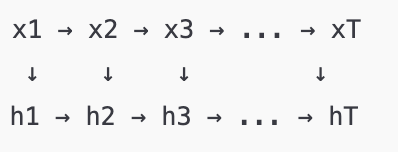

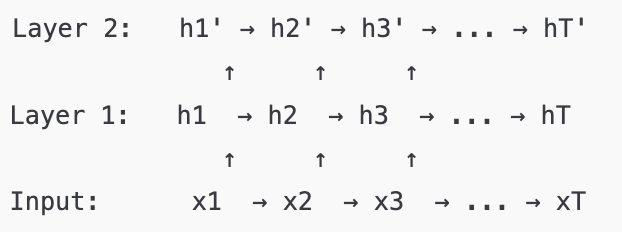

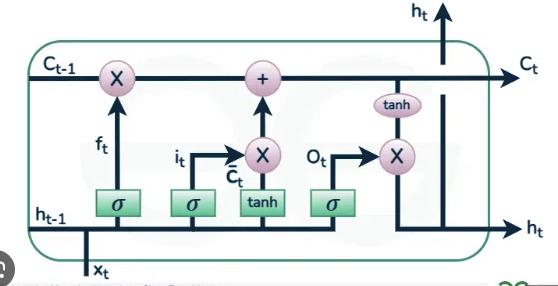

#TRAIN / EVAL LOOP

In [ ]:
import numpy as np
from tqdm import tqdm
import torch


def train_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    epoch: int,
):
    """
    Huấn luyện mô hình trong MỘT epoch.

    Chức năng chính của hàm:
    - Đặt mô hình ở chế độ train
    - Duyệt qua toàn bộ dữ liệu huấn luyện theo từng batch
    - Thực hiện forward → loss → backward → update weights
    - Hiển thị progress bar theo batch
    - Trả về loss trung bình của epoch

    Args:
        model (nn.Module):
            Mô hình PyTorch cần huấn luyện.

        loader (DataLoader):
            DataLoader chứa dữ liệu huấn luyện,
            cung cấp từng batch (x, y).

        optimizer (torch.optim.Optimizer):
            Bộ tối ưu hóa (Adam, SGD, ...).

        criterion (nn.Module):
            Hàm loss (ví dụ: CrossEntropyLoss).

        device (torch.device):
            Thiết bị huấn luyện (CPU hoặc GPU).

        epoch (int):
            Số thứ tự epoch hiện tại (dùng để hiển thị).
    """

    # -----------------------------------
    # 1. Chuyển mô hình sang chế độ train
    # -----------------------------------
    # Bật các thành phần chỉ dùng khi train
    # (Dropout, BatchNorm, ...)
    model.train()

    # Danh sách lưu loss của từng batch
    losses = []

    # -----------------------------------
    # 2. Tạo progress bar với tqdm
    # -----------------------------------
    progress_bar = tqdm(
        loader,                          # DataLoader (duyệt theo batch)
        desc=f"Epoch [{epoch}] Train",   # Mô tả hiển thị
        leave=False,                     # Không giữ lại progress bar cũ
    )

    # -----------------------------------
    # 3. Vòng lặp huấn luyện theo batch
    # -----------------------------------
    for x, y in progress_bar:

        # Đưa dữ liệu lên thiết bị tính toán (CPU / GPU)
        x = x.to(device)
        y = y.to(device)

        # -----------------------------------
        # 3.1 Reset gradient
        # -----------------------------------
        # PyTorch cộng dồn gradient theo batch,
        # nên cần zero_grad() trước mỗi lần backward
        optimizer.zero_grad()

        # -----------------------------------
        # 3.2 Forward pass
        # -----------------------------------
        # logits: (batch_size, num_classes)
        logits = model(x)

        # -----------------------------------
        # 3.3 Tính loss
        # -----------------------------------
        loss = criterion(logits, y)

        # -----------------------------------
        # 3.4 Backward pass
        # -----------------------------------
        # Tính gradient của loss theo các tham số
        loss.backward()

        # -----------------------------------
        # 3.5 Cập nhật trọng số
        # -----------------------------------
        optimizer.step()

        # Lưu loss của batch hiện tại
        losses.append(loss.item())

    # 4. Trả về loss trung bình của epoch
    # -----------------------------------
    return float(np.mean(losses))


In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, epoch):
    model.eval()

    losses, preds, labels = [], [], []

    progress_bar = tqdm(
        loader,
        desc=f"Epoch [{epoch}] Val",
        leave=False,
    )

    for x, y in progress_bar:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        losses.append(loss.item())

        preds.extend(
            torch.argmax(logits, dim=1).cpu().numpy()
        )
        labels.extend(y.cpu().numpy())

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return {
        "loss": float(np.mean(losses)),
        "precision": precision_score(
            labels, preds, average="binary"
        ),
        "recall": recall_score(
            labels, preds, average="binary"
        ),
        "f1": f1_score(
            labels, preds, average="binary"
        ),
    }


#TRAINING

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = LSTMClassifier(
    vocab_size=len(word2idx),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=128,
    num_classes=2,
    embedding_matrix=embedding_matrix,
).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()


In [ ]:
def train_and_evaluate(model, optimizer, criterion, train_loader, val_loader, DEVICE, epochs=10):
    best_f1 = 0.0

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            DEVICE,
            epoch,
        )

        val_metrics = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE,
            epoch,
        )

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"P: {val_metrics['precision']:.4f} | "
            f"R: {val_metrics['recall']:.4f} | "
            f"F1: {val_metrics['f1']:.4f}"
        )

        # -----------------------------
        # Save best model (theo F1)
        # -----------------------------
        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            torch.save(model.state_dict(), "best_model.pt")


In [ ]:
train_and_evaluate(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    DEVICE=DEVICE,
    epochs=10
)

Epoch 01 | Train Loss: 0.6829 | Val Loss: 0.6743 | P: 0.5853 | R: 0.6160 | F1: 0.6003


Epoch 02 | Train Loss: 0.5738 | Val Loss: 0.3789 | P: 0.8578 | R: 0.8130 | F1: 0.8348


Epoch 03 | Train Loss: 0.2964 | Val Loss: 0.3030 | P: 0.8550 | R: 0.8940 | F1: 0.8741


Epoch 04 | Train Loss: 0.1940 | Val Loss: 0.3138 | P: 0.8756 | R: 0.8598 | F1: 0.8676


Epoch 05 | Train Loss: 0.1116 | Val Loss: 0.3780 | P: 0.8849 | R: 0.8240 | F1: 0.8534


Epoch 06 | Train Loss: 0.0575 | Val Loss: 0.4888 | P: 0.8657 | R: 0.8524 | F1: 0.8590


Epoch 07 | Train Loss: 0.0332 | Val Loss: 0.5361 | P: 0.8562 | R: 0.8502 | F1: 0.8532


Epoch 08 | Train Loss: 0.0201 | Val Loss: 0.6326 | P: 0.8462 | R: 0.8670 | F1: 0.8565


Epoch 09 | Train Loss: 0.0151 | Val Loss: 0.7048 | P: 0.8804 | R: 0.7888 | F1: 0.8321


Epoch 10 | Train Loss: 0.0111 | Val Loss: 0.7058 | P: 0.8651 | R: 0.8398 | F1: 0.8522


#Bài tập

1. Dùng Glove 200d và 300d để làm cho embedding layer. Dựa vào best model hãy cho biết kết quả trên 200d và 300d
2. Thay LSTM bằng GRU
3. Dựa vào best model hãy cho biết kết quả khi thay LSTM bằng GRU trên glove 300d


## 1. Dùng Glove 200d và 300d để làm embedding layer

### 1.1 Glove 200d


In [ ]:
GLOVE_PATH = "glove.6B.200d.txt"
EMBEDDING_DIM = 200

word2idx_200d, embedding_matrix_200d, embeddings_200d = load_glove_embeddings(
    GLOVE_PATH, EMBEDDING_DIM
)

In [ ]:
train_loader_200d = DataLoader(
    IMDBDataset(train_df, word2idx_200d),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader_200d = DataLoader(
    IMDBDataset(val_df, word2idx_200d),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader_200d = DataLoader(
    IMDBDataset(test_df, word2idx_200d),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [ ]:
model_glove_200d = LSTMClassifier(
    vocab_size=len(word2idx_200d),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=128,
    num_classes=2,
    embedding_matrix=embedding_matrix_200d,
).to(DEVICE)

optimizer_200d = optim.Adam(model_glove_200d.parameters(), lr=1e-3)

train_and_evaluate(
    model=model_glove_200d,
    optimizer=optimizer_200d,
    criterion=criterion,
    train_loader=train_loader_200d,
    val_loader=val_loader_200d,
    DEVICE=DEVICE,
    epochs=10
)

Epoch 01 | Train Loss: 0.6507 | Val Loss: 0.6854 | P: 0.5051 | R: 0.9712 | F1: 0.6646


Epoch 02 | Train Loss: 0.4821 | Val Loss: 0.3530 | P: 0.8796 | R: 0.8142 | F1: 0.8457


Epoch 03 | Train Loss: 0.2344 | Val Loss: 0.3115 | P: 0.8740 | R: 0.8724 | F1: 0.8732


Epoch 04 | Train Loss: 0.1187 | Val Loss: 0.3765 | P: 0.8723 | R: 0.8540 | F1: 0.8631


Epoch 05 | Train Loss: 0.0549 | Val Loss: 0.4524 | P: 0.8405 | R: 0.8798 | F1: 0.8597


Epoch 06 | Train Loss: 0.0249 | Val Loss: 0.5911 | P: 0.8553 | R: 0.8582 | F1: 0.8567


Epoch 07 | Train Loss: 0.0123 | Val Loss: 0.6917 | P: 0.8595 | R: 0.8442 | F1: 0.8518


Epoch 08 | Train Loss: 0.0076 | Val Loss: 0.7332 | P: 0.8069 | R: 0.8968 | F1: 0.8495


Epoch 09 | Train Loss: 0.0053 | Val Loss: 0.7289 | P: 0.8714 | R: 0.8052 | F1: 0.8370


Epoch 10 | Train Loss: 0.0038 | Val Loss: 0.8833 | P: 0.8522 | R: 0.8606 | F1: 0.8564


In [ ]:
model_glove_200d.load_state_dict(torch.load("best_model.pt"))
model_glove_200d.to(DEVICE)

test_metrics_glove_200d = evaluate(
    model=model_glove_200d,
    loader=test_loader_200d,
    criterion=criterion,
    device=DEVICE,
    epoch="Test"
)

print(
    f"Test Loss: {test_metrics_glove_200d['loss']:.4f} | "
    f"P: {test_metrics_glove_200d['precision']:.4f} | "
    f"R: {test_metrics_glove_200d['recall']:.4f} | "
    f"F1: {test_metrics_glove_200d['f1']:.4f}"
)

Test Loss: 0.3135 | P: 0.8799 | R: 0.8676 | F1: 0.8737


### 1.2 Glove 300d

In [ ]:
GLOVE_PATH = "glove.6B.300d.txt"
EMBEDDING_DIM = 300

word2idx_300d, embedding_matrix_300d, embeddings_300d = load_glove_embeddings(
    GLOVE_PATH, EMBEDDING_DIM
)

In [ ]:
train_loader_300d = DataLoader(
    IMDBDataset(train_df, word2idx_300d),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader_300d = DataLoader(
    IMDBDataset(val_df, word2idx_300d),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader_300d = DataLoader(
    IMDBDataset(test_df, word2idx_300d),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [ ]:
model_glove_300d = LSTMClassifier(
    vocab_size=len(word2idx_300d),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=128,
    num_classes=2,
    embedding_matrix=embedding_matrix_300d,
).to(DEVICE)

optimizer_300d = optim.Adam(model_glove_300d.parameters(), lr=1e-3)

train_and_evaluate(
    model=model_glove_300d,
    optimizer=optimizer_300d,
    criterion=criterion,
    train_loader=train_loader_300d,
    val_loader=val_loader_300d,
    DEVICE=DEVICE,
    epochs=10
)

Epoch 01 | Train Loss: 0.6808 | Val Loss: 0.6713 | P: 0.6910 | R: 0.1972 | F1: 0.3068


Epoch 02 | Train Loss: 0.3968 | Val Loss: 0.3010 | P: 0.8763 | R: 0.8810 | F1: 0.8786


Epoch 03 | Train Loss: 0.1685 | Val Loss: 0.3479 | P: 0.9135 | R: 0.8132 | F1: 0.8604


Epoch 04 | Train Loss: 0.0635 | Val Loss: 0.4461 | P: 0.8416 | R: 0.9086 | F1: 0.8738


Epoch 05 | Train Loss: 0.0259 | Val Loss: 0.6416 | P: 0.8897 | R: 0.8082 | F1: 0.8470


Epoch 06 | Train Loss: 0.0160 | Val Loss: 0.6821 | P: 0.8450 | R: 0.8800 | F1: 0.8622


Epoch 07 | Train Loss: 0.0105 | Val Loss: 0.6818 | P: 0.8341 | R: 0.8826 | F1: 0.8576


Epoch 08 | Train Loss: 0.0047 | Val Loss: 0.7457 | P: 0.8721 | R: 0.8224 | F1: 0.8465


Epoch 09 | Train Loss: 0.0036 | Val Loss: 0.8559 | P: 0.8679 | R: 0.8398 | F1: 0.8536


Epoch 10 | Train Loss: 0.0031 | Val Loss: 1.1371 | P: 0.8848 | R: 0.8066 | F1: 0.8439


In [ ]:
model_glove_300d.load_state_dict(torch.load("best_model.pt"))
model_glove_300d.to(DEVICE)

test_metrics_glove_300d = evaluate(
    model=model_glove_300d,
    loader=test_loader_300d,
    criterion=criterion,
    device=DEVICE,
    epoch="Test"
)

print(
    f"Test Loss: {test_metrics_glove_300d['loss']:.4f} | "
    f"P: {test_metrics_glove_300d['precision']:.4f} | "
    f"R: {test_metrics_glove_300d['recall']:.4f} | "
    f"F1: {test_metrics_glove_300d['f1']:.4f}"
)

Test Loss: 0.2969 | P: 0.8836 | R: 0.8760 | F1: 0.8798


## 2. Thay LSTM bằng GRU

In [ ]:
class GRUClassifier(nn.Module):
    """
    Mô hình phân loại dựa trên mạng nơ-ron hồi tiếp GRU (Gated Recurrent Unit).

    Kiến trúc tổng quát:
        Input (token indices)
            ↓
        Embedding Layer (pretrained / random)
            ↓
        GRU Encoder
            ↓
        Fully Connected Layer
            ↓
        Output (logits cho từng lớp)
    """

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        hidden_dim: int,
        num_classes: int,
        embedding_matrix: torch.Tensor,
    ):
        """
        Hàm khởi tạo mô hình.

        Args:
            vocab_size (int):
                Kích thước từ vựng (số lượng token trong vocab).

            embedding_dim (int):
                Số chiều của vector embedding cho mỗi từ.
                Ví dụ: 100, 200, 300 (GloVe, Word2Vec).

            hidden_dim (int):
                Số chiều của hidden state trong GRU.
                Thể hiện khả năng ghi nhớ ngữ cảnh của mô hình.

            num_classes (int):
                Số lớp đầu ra.
                Ví dụ:
                    - 2 cho bài toán sentiment (positive / negative)

            embedding_matrix (torch.Tensor):
                Ma trận embedding đã được huấn luyện sẵn
                (pretrained embeddings).
                Shape: (vocab_size, embedding_dim)
        """

        # Bắt buộc phải gọi hàm khởi tạo của nn.Module
        super().__init__()

        # -------------------------
        # 1. Embedding Layer
        # -------------------------
        # Chuyển mỗi token index thành vector embedding
        # padding_idx=0 đảm bảo vector của <PAD> luôn là vector 0
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        # Nạp embedding pretrained vào layer
        self.embedding.weight.data.copy_(embedding_matrix)

        # Cho phép fine-tune embedding
        self.embedding.weight.requires_grad = True

        # -------------------------
        # 2. GRU Encoder
        # -------------------------
        # batch_first=True → input shape: (batch_size, seq_len, embedding_dim)
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # -------------------------
        # 3. Fully Connected Layer
        # -------------------------
        # Chuyển hidden state cuối cùng của GRU
        # sang logits cho từng lớp
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Lan truyền xuôi (forward pass) của mô hình.

        Args:
            x (torch.Tensor):
                Tensor chứa index của các token.
                Shape: (batch_size, seq_len)

        Returns:
            torch.Tensor:
                Logits đầu ra cho từng lớp.
                Shape: (batch_size, num_classes)
        """

        # Bước 1: Embedding
        # (batch_size, seq_len)
        #   → (batch_size, seq_len, embedding_dim)
        x = self.embedding(x)

        # Bước 2: GRU
        # Output:
        #   - output: hidden states tại mọi time step (không dùng)
        #   - h_n: hidden state cuối cùng của mỗi layer
        _, h_n = self.gru(x)

        # h_n shape:
        #   (num_layers * num_directions, batch_size, hidden_dim)
        # Với GRU 1 layer, 1 direction:
        #   h_n[-1] → (batch_size, hidden_dim)

        # Bước 3: Fully Connected
        logits = self.fc(h_n[-1])

        return logits


In [ ]:
model_GRU_glove_300d = GRUClassifier(
    vocab_size=len(word2idx_300d),
    embedding_dim=EMBEDDING_DIM,  # 300
    hidden_dim=128,
    num_classes=2,
    embedding_matrix=embedding_matrix_300d,
).to(DEVICE)

optimizer_GRU_300d = optim.Adam(
    model_GRU_glove_300d.parameters(), lr=1e-3
)

train_and_evaluate(
    model=model_GRU_glove_300d,
    optimizer=optimizer_GRU_300d,
    criterion=criterion,
    train_loader=train_loader_300d,
    val_loader=val_loader_300d,
    DEVICE=DEVICE,
    epochs=10
)


Epoch 01 | Train Loss: 0.5330 | Val Loss: 0.3164 | P: 0.8986 | R: 0.8226 | F1: 0.8589


Epoch 02 | Train Loss: 0.2214 | Val Loss: 0.2831 | P: 0.8538 | R: 0.9250 | F1: 0.8880


Epoch 03 | Train Loss: 0.0726 | Val Loss: 0.3584 | P: 0.8776 | R: 0.8794 | F1: 0.8785


Epoch 04 | Train Loss: 0.0194 | Val Loss: 0.5205 | P: 0.8688 | R: 0.8690 | F1: 0.8689


Epoch 05 | Train Loss: 0.0081 | Val Loss: 0.6873 | P: 0.8739 | R: 0.8496 | F1: 0.8616


Epoch 06 | Train Loss: 0.0092 | Val Loss: 0.6288 | P: 0.8623 | R: 0.7980 | F1: 0.8289


Epoch 07 | Train Loss: 0.0317 | Val Loss: 0.6415 | P: 0.8408 | R: 0.8706 | F1: 0.8555


Epoch 08 | Train Loss: 0.0107 | Val Loss: 0.9255 | P: 0.8655 | R: 0.8302 | F1: 0.8475


Epoch 09 | Train Loss: 0.0020 | Val Loss: 0.8298 | P: 0.8576 | R: 0.8418 | F1: 0.8496


Epoch 10 | Train Loss: 0.0024 | Val Loss: 0.9511 | P: 0.8615 | R: 0.8312 | F1: 0.8461


In [ ]:
model_GRU_glove_300d.load_state_dict(torch.load("best_model.pt"))
model_GRU_glove_300d.to(DEVICE)

test_metrics_GRU_glove_300d = evaluate(
    model=model_GRU_glove_300d,
    loader=test_loader_300d,
    criterion=criterion,
    device=DEVICE,
    epoch="Test"
)

print(
    f"Test Loss: {test_metrics_GRU_glove_300d['loss']:.4f} | "
    f"P: {test_metrics_GRU_glove_300d['precision']:.4f} | "
    f"R: {test_metrics_GRU_glove_300d['recall']:.4f} | "
    f"F1: {test_metrics_GRU_glove_300d['f1']:.4f}"
)

Test Loss: 0.2813 | P: 0.8543 | R: 0.9206 | F1: 0.8862


# 3. Dựa vào best model hãy cho biết kết quả khi thay LSTM bằng GRU trên glove 300d

## So sánh LSTM và GRU với Glove 300d

| Model | Test Loss | Precision | Recall | F1-score |
|------|-----------|-----------|--------|----------|
| **LSTM (300d)** | 0.2969 | 0.8836 | 0.8760 | 0.8798 |
| **GRU (300d)**  | **0.2813** | 0.8543 | **0.9206** | **0.8862** |

### Nhận xét

- GRU cho kết quả tốt hơn LSTM về tổng thể, thể hiện qua:
  - Test Loss thấp hơn
  - F1-score cao hơn

- LSTM có Precision cao hơn, tức là Khi dự đoán, LSTM ít nhầm negative với positive hơn.

- GRU có Recall cao hơn đáng kể, nghĩa là GRU bắt được nhiều mẫu positive hơn, ít bỏ sót cảm xúc tích cực trong review.

### Kết luận

- Nếu ưu tiên cân bằng Precision–Recall thì GRU là lựa chọn tốt hơn LSTM.
- Nếu ưu tiên Precision cao thì LSTM vẫn là một lựa chọn phù hợp.